In [1]:
import uuid
from typing import Annotated, Optional, Dict

from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict, List, Any
from langchain_anthropic import AnthropicLLM, ChatAnthropic
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import Tool

from langgraph.checkpoint.memory import MemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
import nest_asyncio
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
import textwrap

from pydantic import BaseModel, Field


In [2]:
load_dotenv(override=True)

True

In [3]:
class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Feedback on the worker's response")
    success_criteria_met: bool = Field(description="Success criteria have been met")
    user_input_needed: bool = Field(description="True if more input is needed from the user or clarification is needed or the assistant is stuck")


In [4]:
class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool

In [5]:
nest_asyncio.apply()
async_browser = create_async_playwright_browser(headless=False)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [6]:
worker_llm = ChatOpenAI(model="gpt-4o-mini")
worker_llm_with_tools = worker_llm.bind_tools(tools)

evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)

In [7]:
async def worker(state: State) -> Dict[str, Any]:
    system_message = f"""You are a helpful assistant that can use tools to complete tasks.
You keep working on a task until either you have a question or clarification for the user, or the success criteria is met.
This is the success criteria:
{state['success_criteria']}
You should reply either with a question for the user about this assignment, or with your final response.
If you have a question for the user, you need to reply by clearly stating your question. An example might be:

Question: please clarify whether you want a summary or a detailed answer

If you've finished, reply with the final answer, and don't ask a question; simply reply with the answer.
"""

    if state.get('feedback_on_work'):
        system_message += f"""
Previously you thought you completed the assignment, but your reply was rejected because the success criteria was not met.
Here is the feedback on why this was rejected:
{state['feedback_on_work']}
With this feedback, please continue the assignment, ensuring that you meet the success criteria or have a question for the user."""

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True

    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages

    response = await worker_llm_with_tools.ainvoke(messages)
    print(f">>> WORKER DONE - tool_calls: {bool(response.tool_calls)}")

    return {
        "messages": [response]
    }


In [8]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]

    route = "tools" if hasattr(last_message, "tool_calls") and last_message.tool_calls else "evaluator"
    print(f">>> ROUTER -> {route}")
    return route


In [9]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Conversation history:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"User: {message}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Tools use]"
            conversation += f"Assistant: {text}\n"
    return conversation


In [10]:
async def evaluator(state: State) -> State:
    last_response = state["messages"][-1].content

    system_message = """You are an evaluator that determines if a task has been completed successfully by an Assistant.
Assess the Assistant's last response based on the given criteria. Respond with your feedback, and with your decision on whether the success criteria has been met,
and whether more input is needed from the user."""

    user_message = f"""You are evaluating a conversation between the User and Assistant. You decide what action to take based on the last response from the Assistant.

The entire conversation with the assistant, with the user's original request and all replies, is:
{format_conversation(state['messages'])}

The success criteria for this assignment is:
{state['success_criteria']}

And the final response from the Assistant that you are evaluating is:
{last_response}

Respond with your feedback, and decide if the success criteria is met by this response.
Also, decide if more user input is required, either because the assistant has a question, needs clarification, or seems to be stuck and unable to answer without help.
"""
    if state["feedback_on_work"]:
        user_message += f"Also, note that in a prior attempt from the Assistant, you provided this feedback: {state['feedback_on_work']}\n"
        user_message += "If you're seeing the Assistant repeating the same mistakes, then consider responding that user input is required."

    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    eval_result = await evaluator_llm_with_output.ainvoke(evaluator_messages)
    print(f">>> EVALUATOR DONE - met: {eval_result.success_criteria_met}, user_input: {eval_result.user_input_needed}")

    new_state = {
        "messages": [{"role": "assistant", "content": f"Evaluator Feedback on this answer: {eval_result.feedback}"}],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state

In [11]:
def route_based_on_evaluation(state: State) -> str:
    result = "END" if state["success_criteria_met"] or state["user_input_needed"] else "worker"
    print(f">>> EVAL ROUTER -> {result}")
    return result

In [12]:
original_tool_node = ToolNode(tools=tools)
async def debug_tools(state: State):
    print(">>> TOOLS STARTED")
    messages = state["messages"]
    last_message = messages[-1]

    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:

        print(">>> NO TOOL CALLS FOUND")
        return {"messages": []}
        tool_results = []

    for tool_call in last_message.tool_calls:

        tool_name = tool_call['name']
        tool_args = tool_call['args']
        print(f">>> Executing: {tool_name} with args: {tool_args}")

        # Find the tool
        tool = next((t for t in tools if t.name == tool_name), None)

        if tool is None:
            print(f">>> Tool not found: {tool_name}")
            continue
        try:
            print(f">>> Calling ainvoke...")
            result = await tool.ainvoke(tool_args)
            print(f">>> Result received: {str(result)[:200]}...")

            tool_results.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_call['id']
            ))

        except Exception as e:
            print(f">>> Tool error: {e}")
            tool_results.append(ToolMessage(
                content=f"Error: {e}",
                tool_call_id=tool_call['id']
            ))

    print(">>> TOOLS DONE")
    return {"messages": tool_results}

In [13]:
graph_builder = StateGraph(State)

graph_builder.add_node("worker", worker)
graph_builder.add_node("evaluator", evaluator)
graph_builder.add_node("tools", debug_tools)

graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

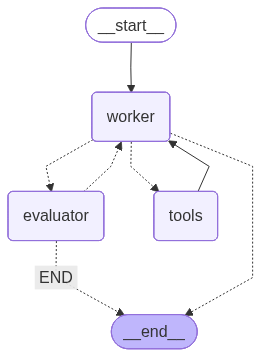

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
def make_thread_id() -> str:
    return str(uuid.uuid4())

async def process_message(message, success_criteria, history, thread):

    config = {"configurable": {"thread_id": thread}}

    state = {
        "messages": message,
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "user_input_needed": False,
        "success_criteria_met": False
    }
    result = await graph.ainvoke(state, config=config)
    user = {"role": "user", "content": message}
    reply = {"role": "assistant", "content": result["messages"][-2].content}
    feedback = {"role": "assistant", "content": result["messages"][-1].content}
    return history + [user, reply, feedback]

async def reset():
    return "", "", None, make_thread_id()

In [16]:
navigate_tool = tools[1]  # navigate_browser
await navigate_tool.ainvoke({"url": "https://www.google.com"})

'Navigating to https://www.google.com returned status code 200'

In [17]:
with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Sidekick Personal Co-worker")
    thread = gr.State(make_thread_id())

    with gr.Row():
        chatbot = gr.Chatbot(label="Sidekick Personal Co-worker", height=300, type="messages")
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Your request to your sidekick")
        with gr.Row():
            success_criteria = gr.Textbox(show_label=False, placeholder="What are your success criteria?")
    with gr.Row():
        reset_button = gr.Button("Reset", variant="stop")
        go_button = gr.Button("Go!", variant="primary")
    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    success_criteria.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

demo.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


>>> WORKER DONE - tool_calls: True
>>> ROUTER -> tools
>>> TOOLS STARTED
>>> Executing: navigate_browser with args: {'url': 'https://www.xe.com/'}
>>> Calling ainvoke...
Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 

>>> Result received: Navigating to https://www.xe.com/ returned status code 200...
>>> Tool error: cannot access local variable 'tool_results' where it is not associated with a value


Traceback (most recent call last):
  File "/var/folders/2v/59gx_ngn74g9f61z289m6xgm0000gn/T/ipykernel_93390/1026199179.py", line 30, in debug_tools
    tool_results.append(ToolMessage(
    ^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'tool_results' where it is not associated with a value

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/vedmuthal/Downloads/personal_agents/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vedmuthal/Downloads/personal_agents/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vedmuthal/Downloads/personal_agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2220,